In [2]:
pip install nltk textblob wordcloud

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from nltk.tokenize import word_tokenize

from textblob import TextBlob

from wordcloud import WordCloud

In [4]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\veda\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\veda\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\veda\AppData\Roaming\nltk_data...


True

In [5]:
df = pd.read_csv(r"C:\Users\veda\Downloads\3) Sentiment dataset.csv")

In [7]:
print(df.head(1))

   Unnamed: 0.1  Unnamed: 0  \
0             0           0   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     

             Timestamp            User    Platform  \
0  2023-01-15 12:30:00   User123         Twitter     

                                     Hashtags  Retweets  Likes     Country  \
0   #Nature #Park                                  15.0   30.0   USA         

   Year  Month  Day  Hour  
0  2023      1   15    12  


In [8]:
df = df[["Text","Sentiment"]]

In [9]:
df["Text"] = df["Text"].str.lower()

In [10]:
df.dropna(inplace=True)

In [14]:
import nltk

nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\veda\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\veda\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\veda\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\veda\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\veda\AppData\Roaming\nltk_data...


True

In [15]:
df["Tokens"] = df["Text"].apply(word_tokenize)

In [16]:
stop_words = set(stopwords.words("english"))

df["Tokens"] = df["Tokens"].apply(
    lambda words: [word for word in words if word.isalpha() and word not in stop_words]
)

In [17]:
lemmatizer = WordNetLemmatizer()

df["Tokens"] = df["Tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [18]:
df["Clean_Text"] = df["Tokens"].apply(lambda words: " ".join(words))

In [19]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Clean_Text"].apply(get_sentiment)

In [20]:
print(df[["Text","Predicted_Sentiment"]].head())

                                                Text Predicted_Sentiment
0   enjoying a beautiful day at the park!        ...            Positive
1   traffic was terrible this morning.           ...            Negative
2   just finished an amazing workout! 💪          ...            Positive
3   excited about the upcoming weekend getaway!  ...            Positive
4   trying out a new recipe for dinner tonight.  ...            Positive


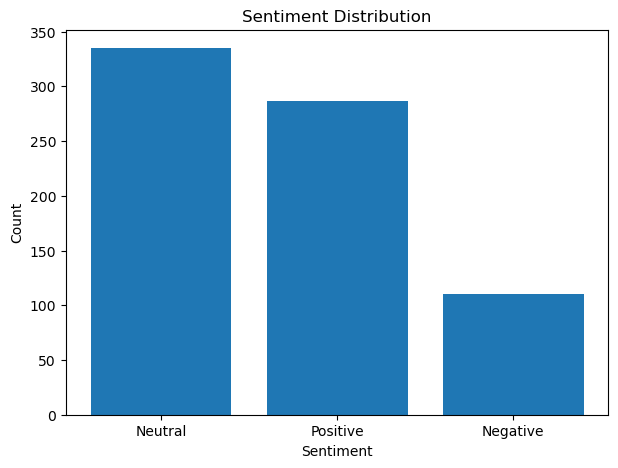

In [21]:
sentiment_counts = df["Predicted_Sentiment"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

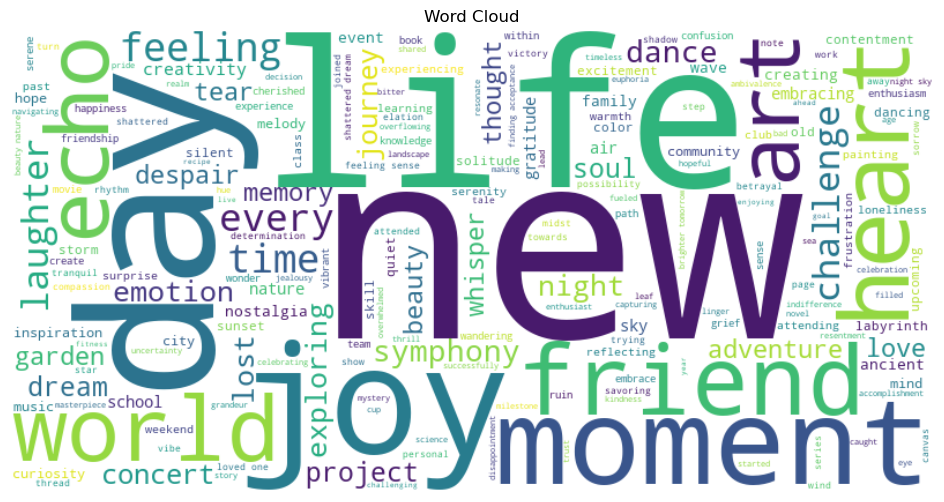

In [22]:
text = " ".join(df["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud")

plt.show()

In [23]:
df.to_csv("sentiment_analysis_results.csv", index=False)